In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Первичный анализ

In [36]:
df = pd.read_csv("forestfires.csv")
df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,aug,sun,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,aug,sun,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,aug,sun,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,aug,sat,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


In [37]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [38]:
df.isna().sum()

X        0
Y        0
month    0
day      0
FFMC     0
DMC      0
DC       0
ISI      0
temp     0
RH       0
wind     0
rain     0
area     0
dtype: int64

#### Из данных первичного анализа мы видим, что:
- Датасет маленький
- Есть категориальные признаки
- Пропусков в данных нет

#### Из числовых характеристик можно сделать некоторые выводы:
- Пожары регистрировались по всей данной территории и большинство пожаров были в центре(т.к. медиана у координат = 4)
- 75% пожаров охватывают менее 6.57 га, что значит что большинство пожаров небольшие, однако есть и редкие случаи больших пожаров
- FFMC в среднем высокий (90.6 при норме < 85), что означает высокую вероятность воспламенения верхних слоев лесной подстилки
- DMC и DC имеют большой разброс, что означает значительные колебания влажности более глубоких слоёв горючего
- ISI в основном низкий (медиана 8.4), но есть экстремальные значения
- Ветер обычно слабый или умеренный 
- Дождь редкий

### 2. Визуальный анализ

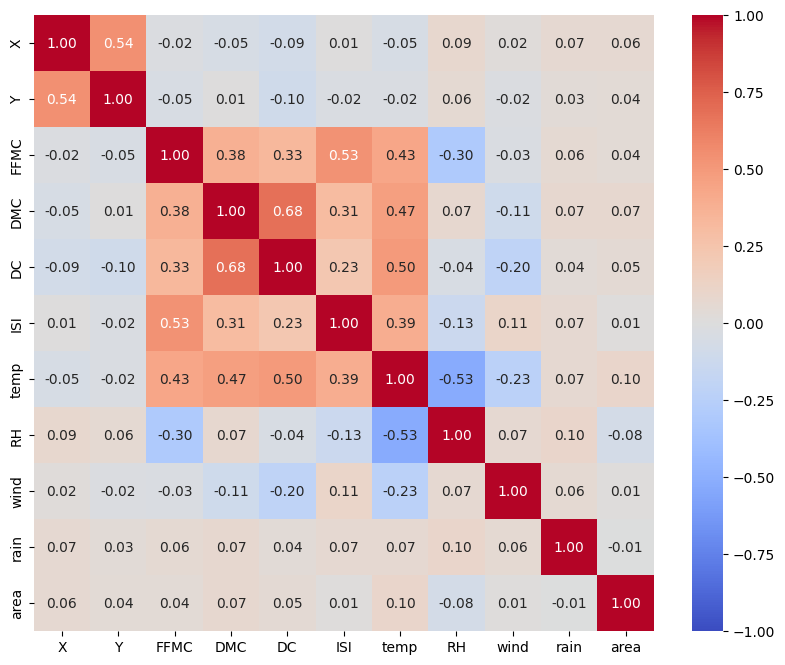

In [39]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,      # Отображение значений внутри ячеек
    cmap='coolwarm', # Цветовая гамма
    fmt=".2f",       # 2 знака после запятой у чисел в ячейках
    vmin=-1, vmax=1  # Границы значений
)
plt.show()

Из данных тепловой карты можно увидеть, что большинство признаков слабо связанны друг с другом, однако также можно сделать вывод, что признаки, относящиеся к системе FWI, связанны друг с другом достаточно сильно, что логично

array([[<Axes: title={'center': 'X'}>, <Axes: title={'center': 'Y'}>,
        <Axes: title={'center': 'FFMC'}>],
       [<Axes: title={'center': 'DMC'}>, <Axes: title={'center': 'DC'}>,
        <Axes: title={'center': 'ISI'}>],
       [<Axes: title={'center': 'temp'}>, <Axes: title={'center': 'RH'}>,
        <Axes: title={'center': 'wind'}>],
       [<Axes: title={'center': 'rain'}>,
        <Axes: title={'center': 'area'}>, <Axes: >]], dtype=object)

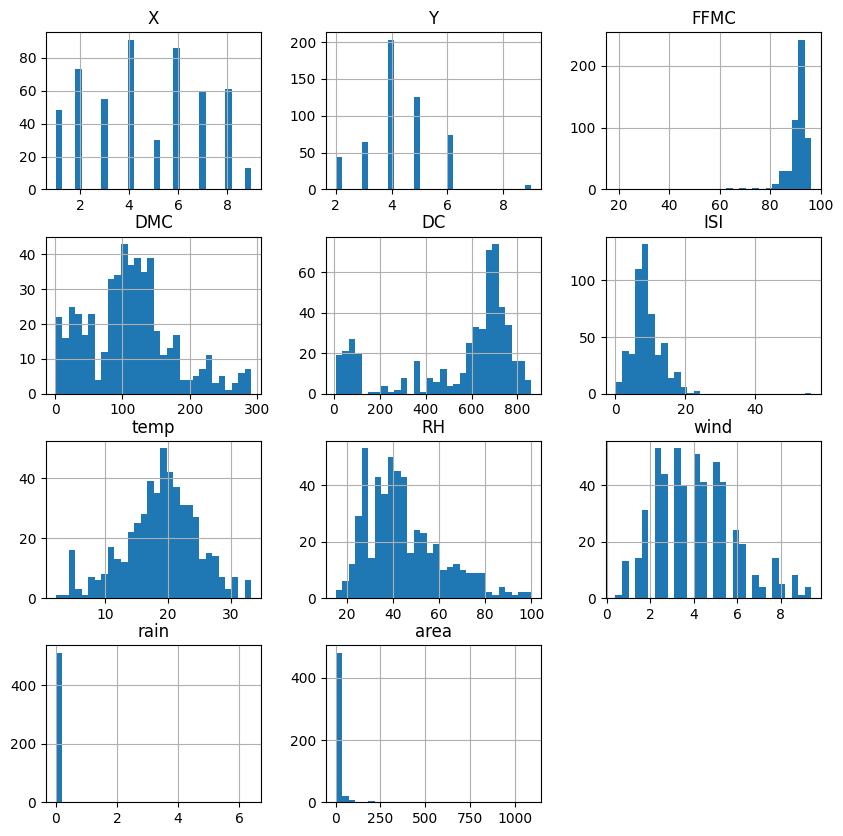

In [40]:
df.hist(figsize=[10,10], bins=30)

#### Из данных гистограмм можно понять, что:
- Распределение координат X и Y неравномерное с преобладанием определенных зон, что значит что большинство пожаров возникают в конкретных районах данной территории.
- В пожарных индексах преобладают низкие/средние значения, что объясняет почему большинство пожарвов остаются маленькими.
- Гистограмма площади пожарок имеет довольно ассиметричное распределение: большой пик ближе к 0 (Большое количество мелких пожаров) и длинный правый хвост (Очень редкие огромные пожары). Длинный правый хвост можно увидеть при увеличении графика, но мне показалось нецелосообразным заострять на этом внимание.

### 3. Предобработка данных

In [41]:
df['month'] = pd.to_datetime(df['month'], format='%b').dt.month
day_map = {'mon': 1, 'tue': 2, 'wed': 3, 'thu': 4, 'fri': 5, 'sat': 6, 'sun':7}
df['day'] = df['day'].map(day_map)
df

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,3,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.00
1,7,4,10,2,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.00
2,7,4,10,6,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.00
3,8,6,3,5,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.00
4,8,6,3,7,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,4,3,8,7,81.6,56.7,665.6,1.9,27.8,32,2.7,0.0,6.44
513,2,4,8,7,81.6,56.7,665.6,1.9,21.9,71,5.8,0.0,54.29
514,7,4,8,7,81.6,56.7,665.6,1.9,21.2,70,6.7,0.0,11.16
515,1,4,8,6,94.4,146.0,614.7,11.3,25.6,42,4.0,0.0,0.00


#### Так как большиснтво моделей работают только с числовыми данными, то дни и месяцы в датафрейме переводим в числа

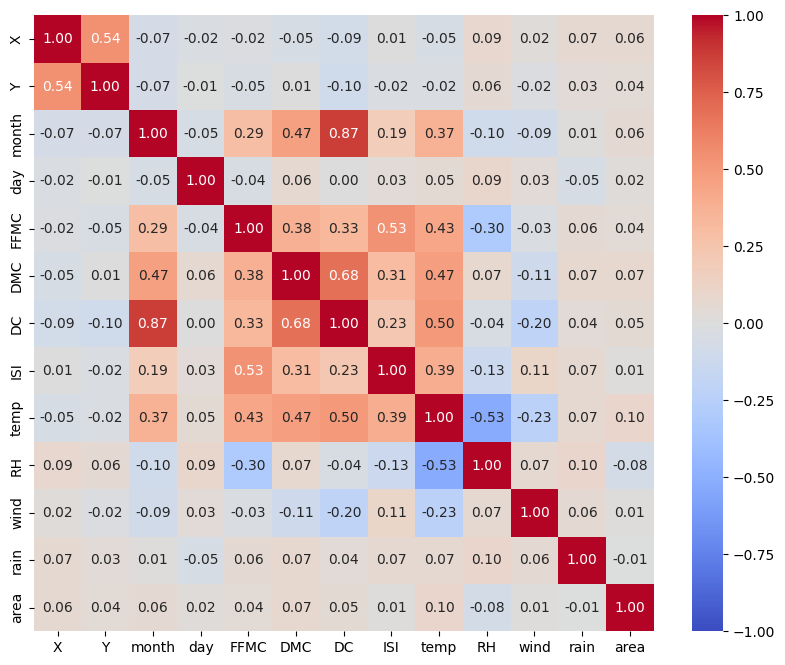

In [42]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,      
    cmap='coolwarm',
    fmt=".2f",       
    vmin=-1, vmax=1 
)
plt.show()

#### Еще раз выведем тепловую карту, чтобы посмотреть с чем коррелируют дни и месяцы. Делаем вывод что месяц коррелирует ирлько с некоторыми индексами FWI, что по моему мнению может быть связано с температурой окружающей среды, а дни ни с чем не коррелируют. 

### 4. Описательная статистика:
- Большиснтво признаков имеют ассиметричное распределение
- Площадь подавляющего большинства пожаров остается сравнительно небольшой
- В показателях FWI преобладают низкие/средние значения, из за чего пожары в большинстве малые 
- Признаки temp, RH, wind имеют распределение близкое к нормальному, меньший разброс значений
- Пожары в большинстве возникают в определенных зонах
##### Типичный сценарий пожара:
- Возникает в определенных зонах парка
- При умеренных погодных условиях
- С низкими/средними индексами пожарной опасности
- Без дождя
- Заканчивается минимальной сгоревшей площадью


### 5. Заключение
В процессе исследования был выполнен анализ набора данных forestfires.csv, включающего сведения о лесных пожарах и сопутствующих метеорологических условиях. Проведён первичный анализ структуры данных, визуализация распределения признаков и их изучение с использованием описательной статистики.

Результаты анализа выявили, что распределение площадей пожаров обладает выраженной асимметрией: преобладают пожары с незначительной площадью, но периодически возникают крупные возгорания. Индексы пожарной опасности и метеорологические показатели имеют разную степень изменчивости, причём наибольший разброс характерен для индексов, отражающих уровень засушливости.

На основе проделанной работы можно заключить, что распространение лесных пожаров носит неоднородный характер, что подчёркивает важность учёта статистических особенностей данных в ходе дальнейшего исследования.